In [ ]:
import numpy as np
import torch
import importlib

# make numpy arrays display with fewer decimals throughout the notebook
np.set_printoptions(precision=4, suppress=True)

from Face import face_inference
from Audio import audio_inference

# reload modules in case they were edited since kernel start
importlib.reload(face_inference)
importlib.reload(audio_inference)

from Face.face_inference import load_face_model, get_face_emotion_from_image, get_face_emotion_from_video_v1
from Audio.audio_inference import get_audio_emotion_vector

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

face_model = load_face_model("./working/best_resemotenet_model.pth")

def predict_emotion(image_path, audio_path):
    # face_vec = get_face_emotion_from_image(image_path, face_model)
    face_vec = get_face_emotion_from_video_v1(image_path, face_model)
    audio_vec = get_audio_emotion_vector(audio_path)
    return face_vec, audio_vec


In [ ]:
# demonstrate converting the returned vectors into a label->probability dict
labels = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

face_vec, audio_vec = predict_emotion(
    "test_data/angry.mp4",
    "test_data/1001_DFA_ANG_XX.wav"
)

# convert numpy floats to native Python floats to avoid np.float32/64 wrappers
face_probs = {lbl: float(prob.round(3)) for lbl, prob in zip(labels, face_vec)}
audio_probs = {lbl: float(prob.round(3)) for lbl, prob in zip(labels, audio_vec)}

print("Face probabilities:")
for emotion, prob in face_probs.items():
    print(f"{emotion}: {prob}")
print("\nAudio probabilities:")
for emotion, prob in audio_probs.items():
    print(f"{emotion}: {prob}")

Face probabilities:
angry: 0.5059999823570251
disgust: 0.07100000232458115
fear: 0.05400000140070915
happy: 0.02500000037252903
neutral: 0.017000000923871994
sad: 0.32499998807907104
surprise: 0.0020000000949949026

Audio probabilities:
angry: 0.314
disgust: 0.152
fear: 0.262
happy: 0.203
neutral: 0.02
sad: 0.035
surprise: 0.002


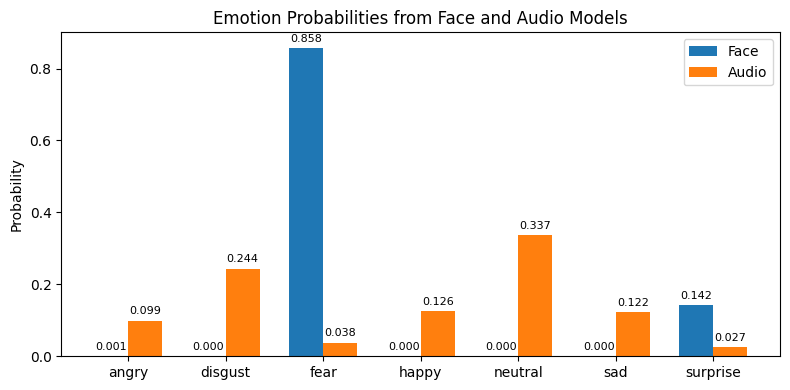

In [17]:

# visualization of the probability vectors
import matplotlib.pyplot as plt
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8,4))
face_bars = ax.bar(x - width/2, face_vec, width, label='Face')
audio_bars = ax.bar(x + width/2, audio_vec, width, label='Audio')

ax.set_ylabel('Probability')
ax.set_title('Emotion Probabilities from Face and Audio Models')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
for bar in face_bars + audio_bars:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [18]:
import numpy as np
from scipy.stats import entropy

labels = ['angry','disgust','fear','happy','neutral','sad','surprise']

def depression_score(face_vec, audio_vec):
    f = np.array(face_vec)
    a = np.array(audio_vec)

    fused = 0.6*f + 0.4*a  # weighted fusion

    sad = fused[labels.index('sad')]
    happy = fused[labels.index('happy')]
    surprise = fused[labels.index('surprise')]

    flatness = entropy(fused)

    score = (
        2.0 * sad
        - 1.5 * happy
        - 0.5 * surprise
        + 0.3 * flatness
    )

    return score

In [19]:
score = depression_score(face_vec, audio_vec)

if score > 0.6:
    print("High Depression Risk")
elif score > 0.3:
    print("Moderate Risk")
else:
    print("Low Risk")

Moderate Risk


In [1]:

import numpy as np

data = np.load('./test_data/DAIC_WOZ/100_P/100_audio_emotion.npy')
print(data)

[0.2039552  0.14012578 0.15158342 0.19714168 0.05048997 0.07613884
 0.13043089]


In [12]:
import numpy as np

data = np.load('../data/processed/train/300.npz')

# See what's inside
print(data.files)

array1 = data["chunks"]  # or use the actual key name
print(array1)

['chunks', 'label']
[[[9.7900002e+01 0.0000000e+00 0.0000000e+00 ... 1.7767381e-02
   1.1193867e-01 1.4021701e-01]
  [2.1639999e+02 0.0000000e+00 0.0000000e+00 ... 1.7767381e-02
   1.1193867e-01 1.4021701e-01]
  [2.0295000e+02 1.0000000e-01 0.0000000e+00 ... 1.7767381e-02
   1.1193867e-01 1.4021701e-01]
  ...
  [2.2695000e+02 0.0000000e+00 0.0000000e+00 ... 1.7767381e-02
   1.1193867e-01 1.4021701e-01]
  [2.0295000e+02 2.0000000e-01 0.0000000e+00 ... 1.7767381e-02
   1.1193867e-01 1.4021701e-01]
  [2.0580000e+02 0.0000000e+00 0.0000000e+00 ... 1.7767381e-02
   1.1193867e-01 1.4021701e-01]]

 [[2.1839999e+02 0.0000000e+00 0.0000000e+00 ... 1.7767381e-02
   1.1193867e-01 1.4021701e-01]
  [1.9595000e+02 0.0000000e+00 0.0000000e+00 ... 1.7767381e-02
   1.1193867e-01 1.4021701e-01]
  [1.8000000e+02 0.0000000e+00 0.0000000e+00 ... 1.7767381e-02
   1.1193867e-01 1.4021701e-01]
  ...
  [1.1950000e+02 5.0000000e-01 6.6450097e-02 ... 1.7767381e-02
   1.1193867e-01 1.4021701e-01]
  [1.7510001e+02